In [1]:
!pip install -q timm seaborn

In [2]:
import os
import zipfile
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

import torchvision.transforms as transforms

import timm

import joblib

In [3]:
os.makedirs("models", exist_ok=True)
os.makedirs("performance", exist_ok=True)

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 8
SEED = 42
N_SPLITS = 5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLASS_NAMES = ["No_DR", "DR"]

MODEL_NAMES = [
    "efficientnet_b3",
    "convnext_tiny",
    "swin_tiny_patch4_window7_224"
]

In [5]:
def set_seed(seed=42):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

    print(f"Seed set to {seed}")

In [6]:
set_seed(SEED)

g = torch.Generator()
g.manual_seed(SEED)

Seed set to 42


In [7]:
zip_path = "/content/DRdataset.zip"

extract_path = "/content/data"

if zipfile.is_zipfile(zip_path):

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:

        zip_ref.extractall(extract_path)


In [8]:
data = []

for label_name in ["DR", "No_DR"]:

    folder = os.path.join(
        extract_path,
        label_name
    )

    for file in os.listdir(folder):

        data.append({

            "path": os.path.join(folder, file),

            "label": 1 if label_name=="DR" else 0
        })

df = pd.DataFrame(data)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


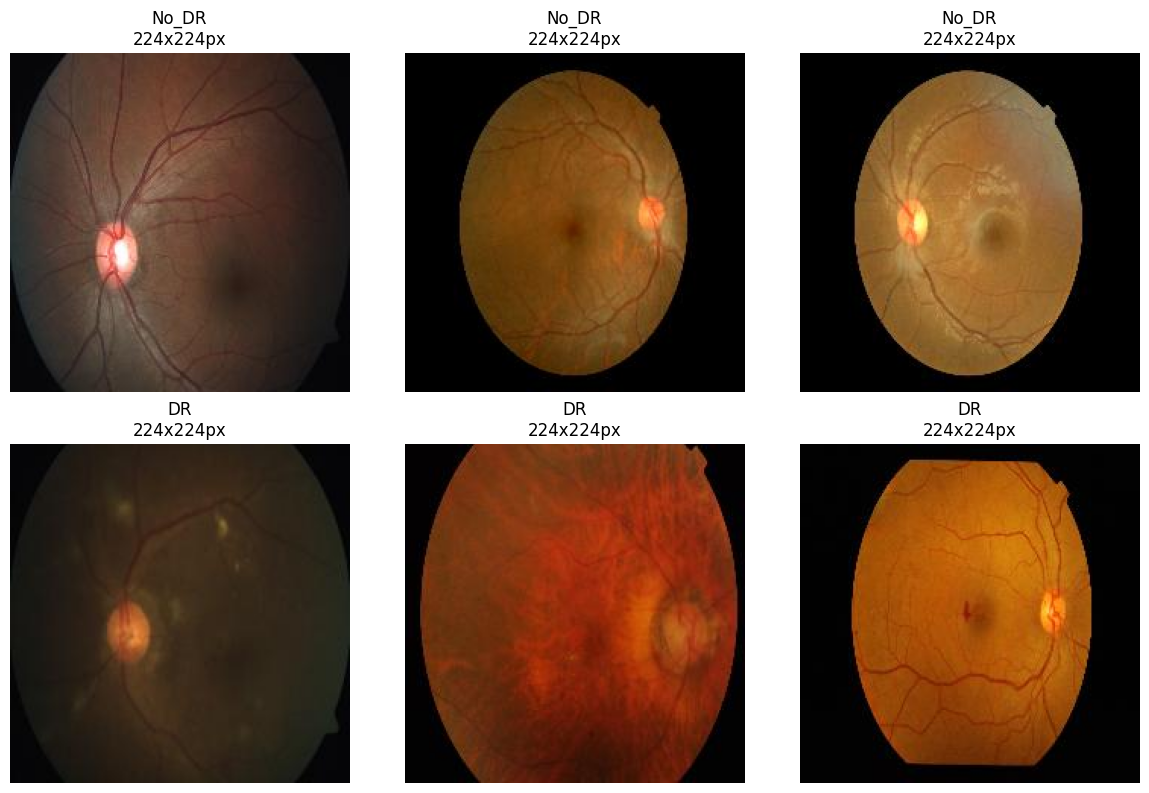

In [9]:
def visualize_images(df):

    plt.figure(figsize=(12,8))

    # Ambil masing-masing 3 data per kelas
    dr_samples = df[df["label"] == 1].sample(
        n=3,
        random_state=42
    )

    no_dr_samples = df[df["label"] == 0].sample(
        n=3,
        random_state=42
    )

    # Gabungkan data
    sample_df = pd.concat(
        [no_dr_samples, dr_samples]
    ).reset_index(drop=True)

    for i in range(len(sample_df)):

        # Load image
        img = Image.open(
            sample_df.loc[i, "path"]
        ).convert("RGB")

        # Plot image
        plt.subplot(2, 3, i + 1)

        plt.imshow(img)

        plt.axis("off")

        # Label kelas
        label = (
            "DR"
            if sample_df.loc[i, "label"] == 1
            else "No_DR"
        )

        # Ukuran gambar
        width, height = img.size

        plt.title(
            f"{label}\n{width}x{height}px"
        )

    plt.tight_layout()

    plt.show()


# Visualisasi 3 citra per kelas
visualize_images(df)

In [10]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Test :", len(test_df))


Train: 2270
Test : 568


In [11]:
def create_loader(df, transform, shuffle=False):

    dataset = RetinaDataset(df, transform)

    loader_args = {
        "dataset": dataset,
        "batch_size": BATCH_SIZE,
        "shuffle": shuffle,
        "num_workers": 0
    }

    if shuffle:
        loader_args["generator"] = g

    return DataLoader(**loader_args)

In [12]:
def crop_retina(img):

    img = np.array(img)

    gray = np.mean(img, axis=2)

    mask = gray > 20

    if mask.sum() == 0:

        return Image.fromarray(img)

    coords = np.argwhere(mask)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)

    img = img[y0:y1, x0:x1]

    return Image.fromarray(img)


In [13]:
def get_transforms(train=True):
    transform_list = [
        transforms.Lambda(crop_retina),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    ]

    if train:
        transform_list.extend([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
        ])

    transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    return transforms.Compose(transform_list)


train_tf = get_transforms(train=True)
val_tf = get_transforms(train=False)

In [14]:
class RetinaDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            row["path"]
        ).convert("RGB")

        label = row["label"]

        if self.transform:

            img = self.transform(img)

        return img, torch.tensor(
            label,
            dtype=torch.float32
        )


In [15]:
MAX_EPOCHS = 30
PATIENCE = 5
BACKBONE_LR = 1e-5
HEAD_LR = 1e-3
POWER_K = 2

In [16]:
class Model(nn.Module):

    def __init__(self, name):

        super().__init__()

        self.model = timm.create_model(
            name,
            pretrained=True
        )

        in_features = self.model.get_classifier().in_features

        self.model.reset_classifier(0)

        self.head = nn.Sequential(

            nn.Linear(in_features, 512),

            nn.BatchNorm1d(512),

            nn.SiLU(),

            nn.Dropout(0.4),

            nn.Linear(512, 128),

            nn.BatchNorm1d(128),

            nn.SiLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.model(x)

        x = self.head(x)

        return x


In [17]:
def compute_metrics(y_true, y_pred):

    y_bin = (y_pred > 0.5).astype(int)

    cm = confusion_matrix(
        y_true,
        y_bin
    )

    cm_percent = (
        cm.astype(float)
        / cm.sum(axis=1, keepdims=True)
    ) * 100

    return {

        "accuracy": accuracy_score(
            y_true,
            y_bin
        ),

        "precision": precision_score(
            y_true,
            y_bin,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_bin,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_bin,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_pred
        ),

        "cm": cm,

        "cm_percent": cm_percent
    }


In [18]:
def plot_cm(
    cm,
    title,
    fmt=".2f",
    save_path=None
):

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.title(title)

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close()

In [19]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0

    preds_all = []
    labels_all = []
    probs_all = []

    with torch.set_grad_enabled(is_train):

        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs).squeeze()

            loss = criterion(outputs, labels.float())

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(outputs)

            running_loss += loss.item()

            probs_all.extend(probs.detach().cpu().numpy())
            preds_all.extend((probs > 0.5).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    metrics = compute_metrics(
        np.array(labels_all),
        np.array(probs_all)
    )

    return running_loss / len(loader), metrics

In [20]:
MODEL_NAMES = [

    "efficientnet_b3",

    "convnext_tiny",

    "swin_tiny_patch4_window7_224"
]

In [21]:
  all_models = []
  all_weights = []

  history_all = {}

  for model_name in MODEL_NAMES:

      print(f"\n========== {model_name} ==========")

      models = []
      fold_aucs = []

      history_all[model_name] = []

      skf = StratifiedKFold(
          n_splits=N_SPLITS,
          shuffle=True,
          random_state=SEED
      )

      for fold, (tr_idx, vl_idx) in enumerate(
          skf.split(train_df, train_df["label"]),
          start=1
      ):

          print(f"\n--- Fold {fold} ---")

          tr_df = train_df.iloc[tr_idx]
          vl_df = train_df.iloc[vl_idx]

          train_loader = create_loader(
              tr_df,
              train_tf,
              shuffle=True
          )

          val_loader = create_loader(
              vl_df,
              val_tf
          )

          model = Model(model_name).to(DEVICE)

          optimizer = optim.Adam([
              {
                  "params": model.model.parameters(),
                  "lr": BACKBONE_LR
              },
              {
                  "params": model.head.parameters(),
                  "lr": HEAD_LR
              }
          ])

          scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
              optimizer,
              T_max=MAX_EPOCHS
          )

          criterion = nn.BCEWithLogitsLoss()

          best_auc = 0.0
          counter = 0

          train_losses = []
          val_losses = []

          train_accs = []
          val_accs = []

          model_path = f"models/{model_name}_fold_{fold}.pth"

          for epoch in range(1, MAX_EPOCHS + 1):

              train_loss, train_metrics = run_epoch(
                  model,
                  train_loader,
                  criterion,
                  optimizer
              )

              val_loss, val_metrics = run_epoch(
                  model,
                  val_loader,
                  criterion
              )

              scheduler.step()

              train_losses.append(train_loss)
              val_losses.append(val_loss)

              train_accs.append(
                  train_metrics["accuracy"]
              )

              val_accs.append(
                  val_metrics["accuracy"]
              )

              print(
                  f"Epoch [{epoch}/{MAX_EPOCHS}] | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Train Acc: {train_metrics['accuracy']:.4f} | "
                  f"Val Acc: {val_metrics['accuracy']:.4f} | "
                  f"Val AUC: {val_metrics['auc']:.4f}"
              )

              if val_metrics["auc"] > best_auc:

                  best_auc = val_metrics["auc"]
                  counter = 0

                  torch.save(
                      model.state_dict(),
                      model_path
                  )

              else:

                  counter += 1

              if counter >= PATIENCE:

                  print("Early Stopping")
                  break

          model.load_state_dict(
              torch.load(
                  model_path,
                  map_location=DEVICE
              )
          )

          models.append(model)
          fold_aucs.append(best_auc)

          history_all[model_name].append({
              "train_loss": train_losses,
              "val_loss": val_losses,
              "train_acc": train_accs,
              "val_acc": val_accs
          })

      weights = np.array(fold_aucs)
      weights /= weights.sum()

      all_models.append(models)
      all_weights.append(weights)


========== efficientnet_b3 ==========

--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Epoch [1/30] | Train Loss: 0.3077 | Val Loss: 0.2841 | Train Acc: 0.8756 | Val Acc: 0.8656 | Val AUC: 0.9777
Epoch [2/30] | Train Loss: 0.2341 | Val Loss: 0.2288 | Train Acc: 0.9174 | Val Acc: 0.9141 | Val AUC: 0.9734
Epoch [3/30] | Train Loss: 0.1885 | Val Loss: 0.1832 | Train Acc: 0.9345 | Val Acc: 0.9493 | Val AUC: 0.9814
Epoch [4/30] | Train Loss: 0.1828 | Val Loss: 0.1659 | Train Acc: 0.9433 | Val Acc: 0.9361 | Val AUC: 0.9871
Epoch [5/30] | Train Loss: 0.1915 | Val Loss: 0.1487 | Train Acc: 0.9339 | Val Acc: 0.9559 | Val AUC: 0.9863
Epoch [6/30] | Train Loss: 0.1583 | Val Loss: 0.1598 | Train Acc: 0.9444 | Val Acc: 0.9339 | Val AUC: 0.9846
Epoch [7/30] | Train Loss: 0.1289 | Val Loss: 0.1376 | Train Acc: 0.9593 | Val Acc: 0.9581 | Val AUC: 0.9879
Epoch [8/30] | Train Loss: 0.1617 | Val Loss: 0.1444 | Train Acc: 0.9444 | Val Acc: 0.9626 | Val AUC: 0.9868
Epoch [9/30] | Train Loss: 0.1308 | Val Loss: 0.1434 | Train Acc: 0.9570 | Val Acc: 0.9559 | Val AUC: 0.9853
Epoch [10/30] | Tra

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch [1/30] | Train Loss: 0.2068 | Val Loss: 0.1560 | Train Acc: 0.9235 | Val Acc: 0.9537 | Val AUC: 0.9830
Epoch [2/30] | Train Loss: 0.1313 | Val Loss: 0.0941 | Train Acc: 0.9565 | Val Acc: 0.9758 | Val AUC: 0.9928
Epoch [3/30] | Train Loss: 0.1293 | Val Loss: 0.0940 | Train Acc: 0.9681 | Val Acc: 0.9714 | Val AUC: 0.9954
Epoch [4/30] | Train Loss: 0.0734 | Val Loss: 0.1072 | Train Acc: 0.9796 | Val Acc: 0.9648 | Val AUC: 0.9945
Epoch [5/30] | Train Loss: 0.0995 | Val Loss: 0.1145 | Train Acc: 0.9719 | Val Acc: 0.9604 | Val AUC: 0.9940
Epoch [6/30] | Train Loss: 0.0806 | Val Loss: 0.0997 | Train Acc: 0.9791 | Val Acc: 0.9802 | Val AUC: 0.9911
Epoch [7/30] | Train Loss: 0.0743 | Val Loss: 0.0964 | Train Acc: 0.9796 | Val Acc: 0.9670 | Val AUC: 0.9951
Epoch [8/30] | Train Loss: 0.0758 | Val Loss: 0.1005 | Train Acc: 0.9802 | Val Acc: 0.9714 | Val AUC: 0.9942
Early Stopping

--- Fold 2 ---
Epoch [1/30] | Train Loss: 0.2089 | Val Loss: 0.1204 | Train Acc: 0.9268 | Val Acc: 0.9626 | Val 

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch [1/30] | Train Loss: 0.2360 | Val Loss: 0.1101 | Train Acc: 0.9185 | Val Acc: 0.9626 | Val AUC: 0.9915
Epoch [2/30] | Train Loss: 0.1327 | Val Loss: 0.1500 | Train Acc: 0.9626 | Val Acc: 0.9449 | Val AUC: 0.9930
Epoch [3/30] | Train Loss: 0.1216 | Val Loss: 0.0925 | Train Acc: 0.9648 | Val Acc: 0.9670 | Val AUC: 0.9949
Epoch [4/30] | Train Loss: 0.1105 | Val Loss: 0.0774 | Train Acc: 0.9703 | Val Acc: 0.9758 | Val AUC: 0.9952
Epoch [5/30] | Train Loss: 0.0826 | Val Loss: 0.0805 | Train Acc: 0.9769 | Val Acc: 0.9758 | Val AUC: 0.9956
Epoch [6/30] | Train Loss: 0.0942 | Val Loss: 0.1150 | Train Acc: 0.9747 | Val Acc: 0.9648 | Val AUC: 0.9894
Epoch [7/30] | Train Loss: 0.1027 | Val Loss: 0.0923 | Train Acc: 0.9747 | Val Acc: 0.9714 | Val AUC: 0.9953
Epoch [8/30] | Train Loss: 0.0809 | Val Loss: 0.0834 | Train Acc: 0.9796 | Val Acc: 0.9692 | Val AUC: 0.9947
Epoch [9/30] | Train Loss: 0.0703 | Val Loss: 0.1184 | Train Acc: 0.9851 | Val Acc: 0.9714 | Val AUC: 0.9943
Epoch [10/30] | Tra

In [22]:
def average_history(histories):

    max_len = max(
        len(h["train_loss"])
        for h in histories
    )

    avg_history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for ep in range(max_len):

        tl, vl = [], []
        ta, va = [], []

        for h in histories:

            if ep < len(h["train_loss"]):

                tl.append(h["train_loss"][ep])
                vl.append(h["val_loss"][ep])

                ta.append(h["train_acc"][ep])
                va.append(h["val_acc"][ep])

        avg_history["train_loss"].append(np.mean(tl))
        avg_history["val_loss"].append(np.mean(vl))

        avg_history["train_acc"].append(np.mean(ta))
        avg_history["val_acc"].append(np.mean(va))

    return avg_history

In [23]:
def plot_history(history, model_name):

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    # LOSS

    axes[0].plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss"
    )

    axes[0].plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation Loss"
    )

    axes[0].set_title(
        f"{model_name} Loss"
    )

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # ACCURACY

    axes[1].plot(
        epochs,
        history["train_acc"],
        marker="o",
        label="Train Accuracy"
    )

    axes[1].plot(
        epochs,
        history["val_acc"],
        marker="o",
        label="Validation Accuracy"
    )

    axes[1].set_title(
        f"{model_name} Accuracy"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(
        f"{model_name} Training Performance"
    )

    plt.tight_layout()

    plt.savefig(
        f"performance/{model_name}_performance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

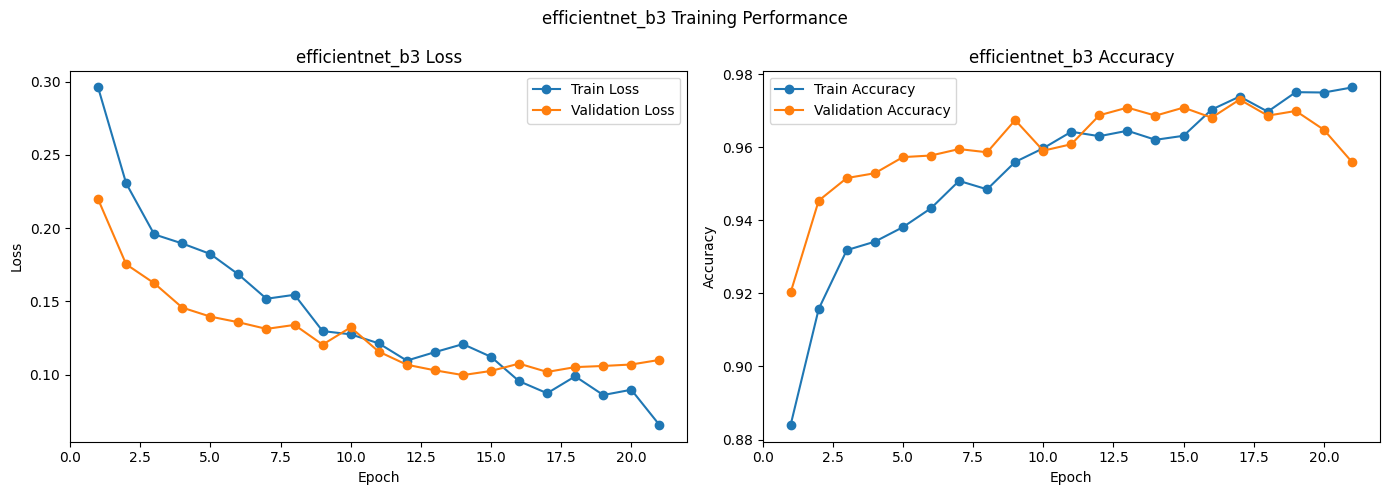

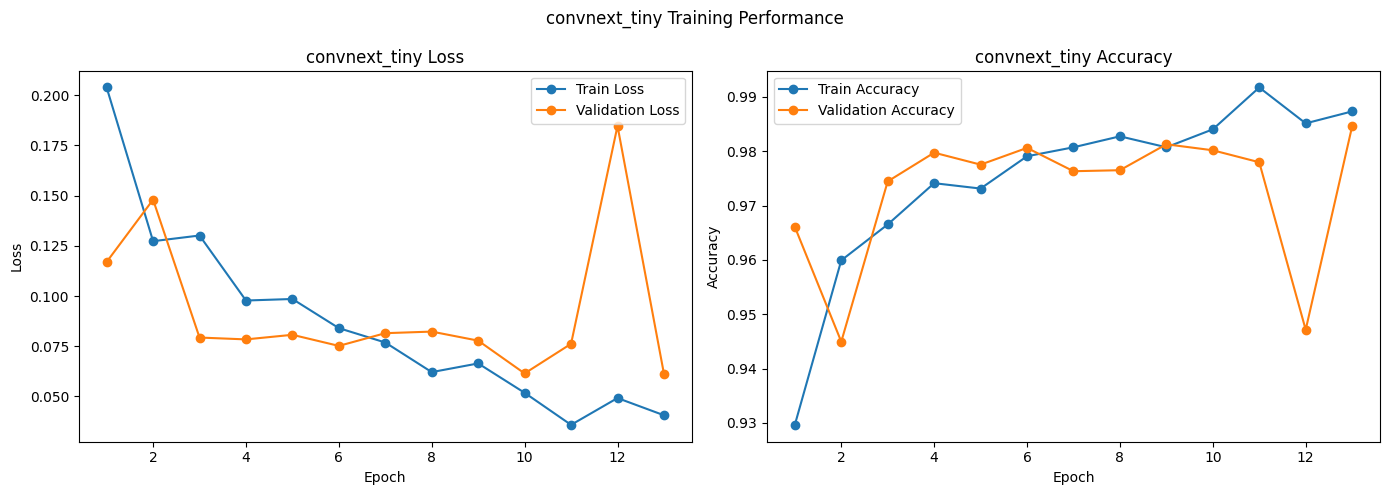

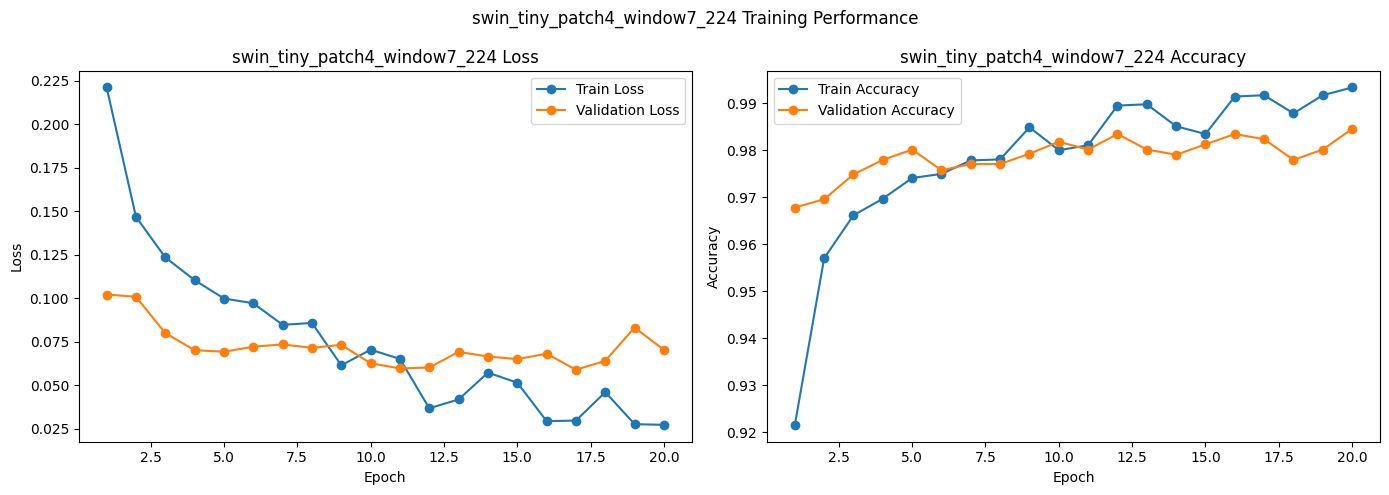

In [24]:
for model_name in MODEL_NAMES:

    avg_history = average_history(
        history_all[model_name]
    )

    plot_history(
        avg_history,
        model_name
    )

In [25]:
test_loader = create_loader(
    test_df,
    val_tf
)

In [26]:
print("\n================================================")
print("BASE LEARNER EVALUATION")
print("================================================")

BASE_NAMES = [

    "EfficientNet-B3",

    "ConvNeXt-Tiny",

    "Swin-Tiny"
]


BASE LEARNER EVALUATION


In [27]:
def predict_base_learner(
    models,
    weights,
    imgs
):

    fold_preds = []

    for model in models:

        model.eval()

        with torch.no_grad():

            pred = torch.sigmoid(
                model(imgs).squeeze(1)
            ).cpu().numpy()

            fold_preds.append(pred)

    fold_preds = np.array(fold_preds)

    # Weighted average antar fold
    weighted_preds = np.average(
        fold_preds,
        axis=0,
        weights=weights
    )

    return weighted_preds

In [28]:
def predict_base_model(
    models,
    weights,
    loader
):

    preds_all = []
    targets_all = []

    # Pastikan seluruh model berada pada mode evaluasi
    for model in models:
        model.eval()

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(DEVICE)

            fold_preds = []

            # Prediksi dari setiap fold
            for model in models:

                probs = torch.sigmoid(
                    model(imgs).squeeze(1)
                ).cpu().numpy()

                fold_preds.append(probs)

            fold_preds = np.array(fold_preds)

            # Weighted average antar fold
            preds = np.average(
                fold_preds,
                axis=0,
                weights=weights
            )

            preds_all.extend(preds)
            targets_all.extend(labels.numpy())

    return (
        np.array(targets_all),
        np.array(preds_all)
    )


========== EfficientNet-B3 ==========
Accuracy : 0.9648
Precision: 0.9645
Recall   : 0.9645
F1 Score : 0.9645
AUC      : 0.9898

Confusion Matrix (Count):
[[276  10]
 [ 10 272]]


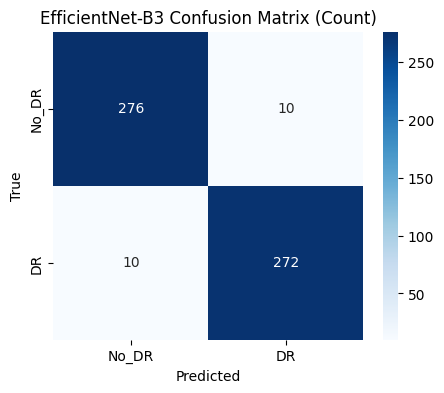


Confusion Matrix (%):
[[96.5   3.5 ]
 [ 3.55 96.45]]


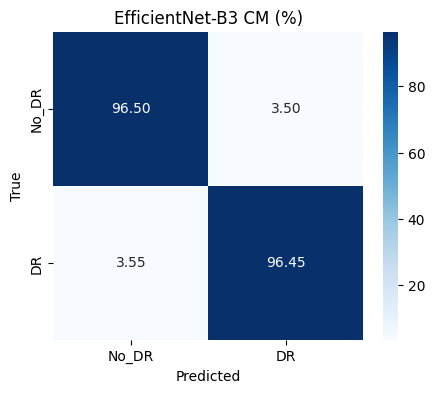


========== ConvNeXt-Tiny ==========
Accuracy : 0.9824
Precision: 0.9789
Recall   : 0.9858
F1 Score : 0.9823
AUC      : 0.9966

Confusion Matrix (Count):
[[280   6]
 [  4 278]]


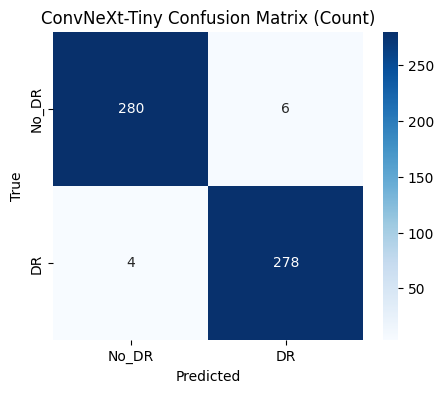


Confusion Matrix (%):
[[97.9   2.1 ]
 [ 1.42 98.58]]


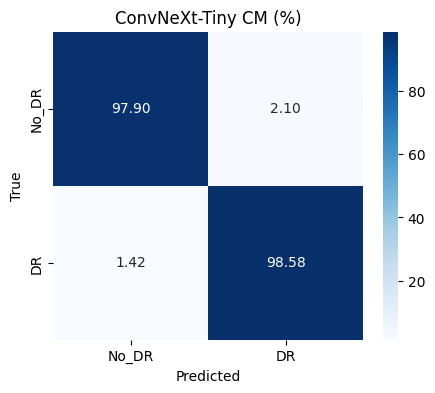


========== Swin-Tiny ==========
Accuracy : 0.9806
Precision: 0.9788
Recall   : 0.9823
F1 Score : 0.9805
AUC      : 0.9988

Confusion Matrix (Count):
[[280   6]
 [  5 277]]


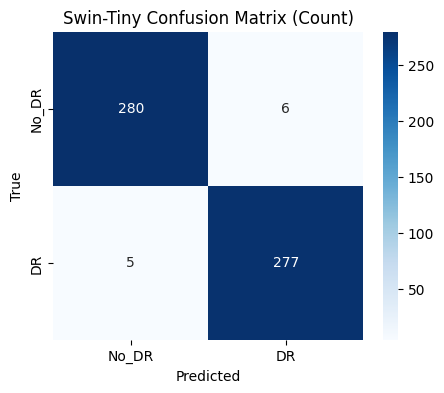


Confusion Matrix (%):
[[97.9   2.1 ]
 [ 1.77 98.23]]


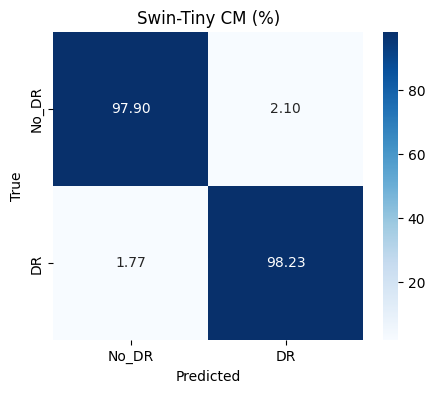

In [90]:
results_table = {}

base_f1s = []

for base_name, models, weights in zip(
    BASE_NAMES,
    all_models,
    all_weights
):

    print(f"\n========== {base_name} ==========")

    y_true, y_pred = predict_base_model(
        models,
        weights,
        test_loader
    )

    metrics = compute_metrics(
        y_true,
        y_pred
    )

    results_table[base_name] = [

        metrics["accuracy"],
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["auc"]
    ]

    base_f1s.append(
        metrics["auc"]
    )

    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1 Score : {metrics['f1']:.4f}")
    print(f"AUC      : {metrics['auc']:.4f}")

    print("\nConfusion Matrix (Count):")
    print(metrics["cm"])

    plot_cm(
        metrics["cm"],
        f"{base_name} Confusion Matrix (Count)",
        "d"
    )

    print("\nConfusion Matrix (%):")
    print(
        np.round(
            metrics["cm_percent"],
            2
        )
    )

    plot_cm(
        metrics["cm_percent"],
        f"{base_name} CM (%)",
        ".2f",
        f"performance/{base_name}_cm.png"
    )

In [119]:
# ==========================================
# BASE MODEL WEIGHTS
# ==========================================
TEMPERATURE = 200

BASE_MODEL_WEIGHTS = np.exp(
    TEMPERATURE * np.array(base_f1s)
)

BASE_MODEL_WEIGHTS /= BASE_MODEL_WEIGHTS.sum()

print("\nBASE MODEL WEIGHTS")
print(
    np.round(
        BASE_MODEL_WEIGHTS,
        4
    )
)


BASE MODEL WEIGHTS
[0.0919 0.3576 0.5505]


In [120]:
def ensemble_comparison(
    all_models,
    all_weights,
    loader,
    power_list=[1, 2, 3, 4]
):

    comparison_results = {}

    # ==========================================
    # SET EVAL MODE
    # ==========================================

    for models in all_models:
        for model in models:
            model.eval()

    # ==========================================
    # HITUNG BASE LEARNER SCORE SATU KALI
    # ==========================================

    base_scores = []

    with torch.no_grad():

        for models, weights in zip(
            all_models,
            all_weights
        ):

            preds = []
            targets = []

            for imgs, labels in loader:

                imgs = imgs.to(DEVICE)

                weighted_preds = predict_base_learner(
                    models,
                    weights,
                    imgs
                )

                preds.extend(weighted_preds)
                targets.extend(labels.numpy())

            metrics = compute_metrics(
                np.array(targets),
                np.array(preds)
            )

            base_scores.append(
                metrics["f1"]
            )

    base_scores = np.array(base_scores)

    print("\nBase Model Scores (AUC)")
    print(np.round(base_scores, 4))

    # ==========================================
    # LOOP POWER
    # ==========================================

    for power in power_list:

        print(f"\n========== POWER VOTING {power} ==========")

        # ==========================================
        # POWER WEIGHTS
        # ==========================================

        TEMPERATURE = 200

        power_weights = np.exp(
            TEMPERATURE * base_scores
        )

        power_weights /= (
            power_weights.sum()
        )

        print(
            "Power Weights:",
            np.round(power_weights, 4)
        )

        preds = []
        targets = []

        with torch.no_grad():

            for imgs, labels in loader:

                imgs = imgs.to(DEVICE)

                model_preds = []

                # Prediksi tiap base model
                for models, weights in zip(
                    all_models,
                    all_weights
                ):

                    weighted_preds = predict_base_learner(
                        models,
                        weights,
                        imgs
                    )

                    model_preds.append(
                        weighted_preds
                    )

                model_preds = np.array(
                    model_preds
                )

                # Power Voting antar base model
                model_preds = (
                    model_preds ** power
                )

                final_preds = np.average(
                    model_preds,
                    axis=0,
                    weights=power_weights
                )

                preds.extend(final_preds)
                targets.extend(labels.numpy())

        preds = np.array(preds)
        targets = np.array(targets)

        metrics = compute_metrics(
            targets,
            preds
        )

        comparison_results[
            f"Power-{power}"
        ] = [

            metrics["accuracy"],
            metrics["precision"],
            metrics["recall"],
            metrics["f1"],
            metrics["auc"]

        ]

        print(
            f"Accuracy : {metrics['accuracy']:.4f}"
        )

        print(
            f"Precision: {metrics['precision']:.4f}"
        )

        print(
            f"Recall   : {metrics['recall']:.4f}"
        )

        print(
            f"F1 Score : {metrics['f1']:.4f}"
        )

        print(
            f"AUC      : {metrics['auc']:.4f}"
        )

    df_comparison = pd.DataFrame(

        comparison_results,

        index=[

            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "AUC"

        ]

    ).round(4)

    print("\n================================================")
    print("POWER VOTING COMPARISON")
    print("================================================")

    display(df_comparison)

    return df_comparison

In [121]:
def calibrate(y_true, y_pred):

    lr = LogisticRegression()

    lr.fit(
        y_pred.reshape(-1,1),
        y_true
    )

    calibrated = lr.predict_proba(
        y_pred.reshape(-1,1)
    )[:,1]

    return calibrated


In [122]:
def plot_calibration_curve(
    y_true,
    y_pred,
    save_path
):

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_pred,
        n_bins=6,
        strategy="quantile"
    )

    plt.figure(figsize=(7,7))

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label="Calibrated Model"
    )

    plt.plot(
        [0,1],
        [0,1],
        "--",
        linewidth=2,
        label="Perfect Calibration"
    )

    plt.grid(alpha=0.3)

    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")

    plt.title("Calibration Curve")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [123]:
def plot_roc_curve(
    y_true,
    y_pred,
    save_path
):

    fpr, tpr, _ = roc_curve(
        y_true,
        y_pred
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        "--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [125]:
def ensemble(
    all_models,
    all_weights,
    loader,
    power=2
):

    preds_all = []
    targets_all = []

    # Set seluruh model ke evaluation mode
    for models in all_models:
        for model in models:
            model.eval()

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(DEVICE)

            model_preds = []

            # ==========================================
            # Prediksi tiap base learner
            # ==========================================
            for models, weights in zip(
                all_models,
                all_weights
            ):

                fold_preds = []

                # Prediksi dari seluruh fold
                for model in models:

                    probs = torch.sigmoid(
                        model(imgs).squeeze(1)
                    ).cpu().numpy()

                    fold_preds.append(probs)

                fold_preds = np.array(fold_preds)

                # Weighted average antar fold
                weighted_preds = np.average(
                    fold_preds,
                    axis=0,
                    weights=weights
                )

                model_preds.append(
                    weighted_preds
                )

            # ==========================================
            # Ensemble antar base model
            # ==========================================
            model_preds = np.array(model_preds)

            # Power Voting antar base model
            model_preds = model_preds ** power

            final_preds = np.average(
                model_preds,
                axis=0,
                weights=BASE_MODEL_WEIGHTS
            )

            preds_all.extend(
                final_preds
            )

            targets_all.extend(
                labels.numpy()
            )

    return (
        np.array(targets_all),
        np.array(preds_all)
    )

In [126]:
def evaluate_power_voting(
    power_values=[1,2,3,4]
):

    comparison_results = {}

    for power_k in power_values:

        y_true_cmp, y_pred_cmp = ensemble(
            all_models,
            all_weights,
            test_loader,
            power=power_k
        )

        metrics_cmp = compute_metrics(
            y_true_cmp,
            y_pred_cmp
        )

        comparison_results[f"Power-{power_k}"] = [

            metrics_cmp["accuracy"],
            metrics_cmp["precision"],
            metrics_cmp["recall"],
            metrics_cmp["f1"],
            metrics_cmp["auc"]
        ]

    return pd.DataFrame(

        comparison_results,

        index=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "AUC"
        ]
    ).round(4)

,Power-1,Power-2,Power-3,Power-4
Accuracy,0.9806,0.9824,0.9736,0.9665
Precision,0.9788,0.9857,0.9855,0.9852
Recall,0.9823,0.9787,0.9610,0.9468
F1-Score,0.9805,0.9822,0.9731,0.9656
AUC,0.9977,0.9973,0.9969,0.9968


Calibrator saved.


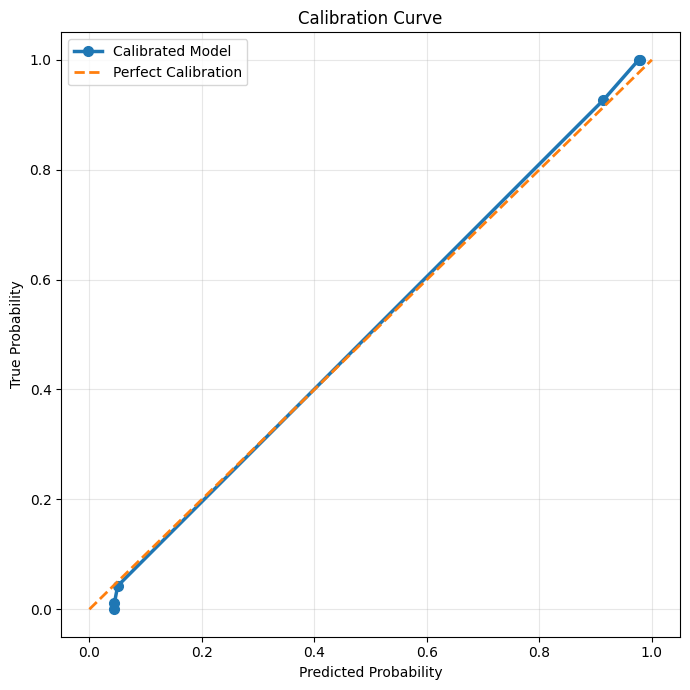


========== ENSEMBLE POWER k=2 ==========

Accuracy : 0.9806338028169014
Precision: 0.9822064056939501
Recall   : 0.9787234042553191
F1 Score : 0.9804618117229129
AUC      : 0.9972846302633537


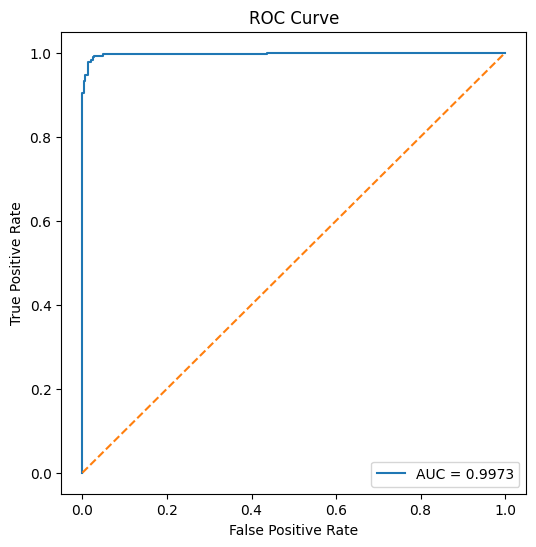

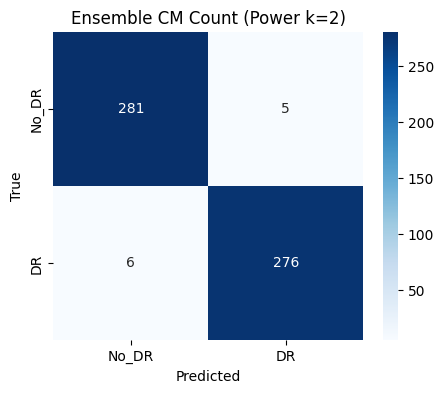

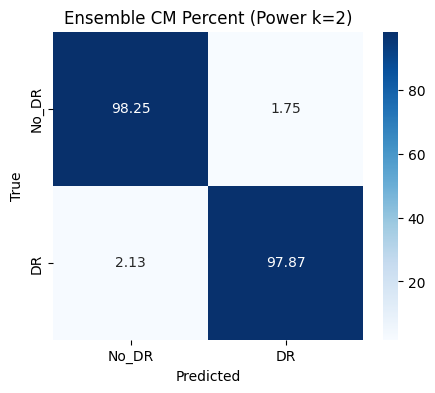

In [127]:
# ==========================================
# POWER COMPARISON
# ==========================================

df_comparison = evaluate_power_voting()

display(df_comparison)

# ==========================================
# FINAL ENSEMBLE
# ==========================================

POWER_K = 2

# ==========================================
# VALIDATION PREDICTION
# ==========================================

val_true, val_pred = ensemble(
    all_models,
    all_weights,
    val_loader,
    power=POWER_K
)

# ==========================================
# TRAIN PLATT SCALING
# ==========================================

calibrator = LogisticRegression()

calibrator.fit(
    val_pred.reshape(-1, 1),
    val_true
)

joblib.dump(
    calibrator,
    "calibrator.pkl"
)

print("Calibrator saved.")

# ==========================================
# TEST PREDICTION
# ==========================================

y_true, y_pred = ensemble(
    all_models,
    all_weights,
    test_loader,
    power=POWER_K
)

# ==========================================
# APPLY CALIBRATION
# ==========================================

y_pred_cal = calibrator.predict_proba(
    y_pred.reshape(-1, 1)
)[:, 1]

# ==========================================
# SAVE PREDICTIONS
# ==========================================

ensemble_results = pd.DataFrame({
    "True_Label": y_true,
    "Ensemble_Probability": y_pred,
    "Calibrated_Probability": y_pred_cal
})

ensemble_results.to_csv(
    "performance/ensemble_predictions.csv",
    index=False
)

# ==========================================
# CALIBRATION CURVE
# ==========================================

plot_calibration_curve(
    y_true,
    y_pred_cal,
    "performance/calibration_curve.png"
)

# ==========================================
# METRICS
# ==========================================

ensemble_metrics = compute_metrics(
    y_true,
    y_pred_cal
)

pd.DataFrame(
    [ensemble_metrics]
).to_csv(
    "performance/ensemble_metrics.csv",
    index=False
)

print(
    f"\n========== ENSEMBLE POWER k={POWER_K} ==========\n"
)

print(
    "Accuracy :",
    ensemble_metrics["accuracy"]
)

print(
    "Precision:",
    ensemble_metrics["precision"]
)

print(
    "Recall   :",
    ensemble_metrics["recall"]
)

print(
    "F1 Score :",
    ensemble_metrics["f1"]
)

print(
    "AUC      :",
    ensemble_metrics["auc"]
)

# ==========================================
# ROC CURVE
# ==========================================

plot_roc_curve(
    y_true,
    y_pred_cal,
    "performance/roc_curve.png"
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

plot_cm(
    ensemble_metrics["cm"],
    f"Ensemble CM Count (Power k={POWER_K})",
    "d",
    "performance/ensemble_cm_count.png"
)

plot_cm(
    ensemble_metrics["cm_percent"],
    f"Ensemble CM Percent (Power k={POWER_K})",
    ".2f",
    "performance/ensemble_cm_percent.png"
)

In [130]:
print(BASE_MODEL_WEIGHTS)

[0.0918788  0.35759285 0.55052835]


In [131]:
def predict_single_model(models, weights, loader):

    preds = []
    targets = []

    for imgs, labels in loader:

        imgs = imgs.to(DEVICE)

        fold_preds = []

        for model in models:

            model.eval()

            with torch.no_grad():

                out = torch.sigmoid(
                    model(imgs).squeeze(1)
                ).cpu().numpy()

            fold_preds.append(out)

        fold_preds = np.array(fold_preds)

        weighted_preds = np.average(
            fold_preds,
            axis=0,
            weights=weights
        )

        preds.extend(weighted_preds)
        targets.extend(labels.numpy())

    return np.array(targets), np.array(preds)

In [132]:
# ==========================================
# SAVE PREDICTION OF ALL DATASET
# ==========================================

all_loader = DataLoader(
    RetinaDataset(df, val_tf),
    batch_size=8,
    shuffle=False
)

# ==========================================
# ENSEMBLE PREDICTION
# ==========================================

y_true_all, y_pred_all = ensemble(
    all_models,
    all_weights,
    all_loader,
    power=POWER_K
)

# ==========================================
# APPLY PLATT SCALING
# ==========================================

y_pred_cal_all = calibrator.predict_proba(
    y_pred_all.reshape(-1, 1)
)[:, 1]

# ==========================================
# CREATE DATAFRAME
# ==========================================

all_dataset_ensemble = df.copy()

all_dataset_ensemble["true_label"] = (
    y_true_all
)

all_dataset_ensemble["ensemble_probability"] = (
    y_pred_all
)

all_dataset_ensemble["ensemble_calibrated_probability"] = (
    y_pred_cal_all
)

all_dataset_ensemble["ensemble_prediction"] = (
    y_pred_cal_all >= 0.5
).astype(int)

# ==========================================
# CLASS NAME
# ==========================================

all_dataset_ensemble["true_class"] = (
    all_dataset_ensemble["true_label"]
    .map({
        0: "No_DR",
        1: "DR"
    })
)

all_dataset_ensemble["predicted_class"] = (
    all_dataset_ensemble["ensemble_prediction"]
    .map({
        0: "No_DR",
        1: "DR"
    })
)

# ==========================================
# CORRECT / WRONG
# ==========================================

all_dataset_ensemble["result"] = np.where(
    all_dataset_ensemble["true_label"]
    ==
    all_dataset_ensemble["ensemble_prediction"],
    "Correct",
    "Wrong"
)

# ==========================================
# SAVE CSV
# ==========================================

all_dataset_ensemble.to_csv(
    "all_dataset_ensemble.csv",
    index=False
)

print("all_dataset_ensemble.csv saved")
print("Total images:", len(all_dataset_ensemble))

all_dataset_ensemble.csv saved
Total images: 2838


In [129]:
# ==========================================
# CONVNEXT-TINY
# ==========================================

convnext_models = all_models[1]

convnext_weights = all_weights[1]

# ==========================================
# ALL DATASET LOADER
# ==========================================

all_loader = DataLoader(
    RetinaDataset(df, val_tf),
    batch_size=8,
    shuffle=False
)

# ==========================================
# PREDICT ALL DATASET
# ==========================================

y_true_convnext_all, y_pred_convnext_all = predict_single_model(

    convnext_models,

    convnext_weights,

    all_loader
)

# ==========================================
# SAVE CSV
# ==========================================

test_dataset_convnext = df.copy()

test_dataset_convnext["true_label"] = y_true_convnext_all

test_dataset_convnext["convnext_probability"] = (
    y_pred_convnext_all
)

test_dataset_convnext["convnext_prediction"] = (
    y_pred_convnext_all >= 0.5
).astype(int)

test_dataset_convnext.to_csv(
    "test_dataset_convnext.csv",
    index=False
)

print("test_dataset_convnext.csv saved")

test_dataset_convnext.csv saved


In [133]:
# ==========================================
# SWIN-TINY
# ==========================================

swin_models = all_models[2]

swin_weights = all_weights[2]

# ==========================================
# ALL DATASET LOADER
# ==========================================

all_loader = DataLoader(
    RetinaDataset(df, val_tf),
    batch_size=8,
    shuffle=False
)

# ==========================================
# PREDICT ALL DATASET
# ==========================================

y_true_swin_all, y_pred_swin_all = predict_single_model(

    swin_models,

    swin_weights,

    all_loader
)

# ==========================================
# SAVE CSV
# ==========================================

test_dataset_swin = df.copy()

test_dataset_swin["true_label"] = y_true_swin_all

test_dataset_swin["swin_probability"] = (
    y_pred_swin_all
)

test_dataset_swin["swin_prediction"] = (
    y_pred_swin_all >= 0.5
).astype(int)

test_dataset_swin.to_csv(
    "test_dataset_swin.csv",
    index=False
)

print("test_dataset_swin.csv saved")

test_dataset_swin.csv saved


In [102]:
for p in [2,3,4]:

    w = np.array(base_f1s) ** p
    w /= w.sum()

    print(f"Power {p}:")
    print(np.round(w, 6))

Power 2:
[0.329821 0.334365 0.335814]
Power 3:
[0.328072 0.334874 0.337054]
Power 4:
[0.326327 0.33538  0.338293]


In [40]:
ensemble_config = {

    "model_names": [

        "efficientnet_b3",

        "convnext_tiny",

        "swin_tiny_patch4_window7_224"
    ],

    "model_paths": {

        "efficientnet_b3": [

            "models/efficientnet_b3_fold_1.pth",
            "models/efficientnet_b3_fold_2.pth",
            "models/efficientnet_b3_fold_3.pth",
            "models/efficientnet_b3_fold_4.pth",
            "models/efficientnet_b3_fold_5.pth"
        ],

        "convnext_tiny": [

            "models/convnext_tiny_fold_1.pth",
            "models/convnext_tiny_fold_2.pth",
            "models/convnext_tiny_fold_3.pth",
            "models/convnext_tiny_fold_4.pth",
            "models/convnext_tiny_fold_5.pth"
        ],

        "swin_tiny_patch4_window7_224": [

            "models/swin_tiny_patch4_window7_224_fold_1.pth",
            "models/swin_tiny_patch4_window7_224_fold_2.pth",
            "models/swin_tiny_patch4_window7_224_fold_3.pth",
            "models/swin_tiny_patch4_window7_224_fold_4.pth",
            "models/swin_tiny_patch4_window7_224_fold_5.pth"
        ]
    },

    "weights": all_weights,

    "base_model_weights":

        BASE_MODEL_WEIGHTS.tolist(),

    "power_k": POWER_K,

    "class_names": [

        "No_DR",

        "DR"
    ]
}

torch.save(
    ensemble_config, "ensemble_config.pth"
)
print("ensemble_config.pth saved")

ensemble_config.pth saved


In [41]:
# =========================================================
# GENERATE requirements.txt
# =========================================================

import torch
import torchvision
import timm
import sklearn
import numpy
import pandas
import PIL
import matplotlib
import seaborn
import joblib

requirements = [
    f"torch=={torch.__version__}",
    f"torchvision=={torchvision.__version__}",
    f"timm=={timm.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"numpy=={numpy.__version__}",
    f"pandas=={pandas.__version__}",
    f"Pillow=={PIL.__version__}",
    f"matplotlib=={matplotlib.__version__}",
    f"seaborn=={seaborn.__version__}",
    f"joblib=={joblib.__version__}",
    "streamlit"
]

with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements))

print("requirements.txt created successfully")

requirements.txt created successfully


In [42]:
with open("requirements.txt", "r") as f:

    print(f.read())

torch==2.11.0+cu128
torchvision==0.26.0+cu128
timm==1.0.27
scikit-learn==1.6.1
numpy==2.0.2
pandas==2.2.2
Pillow==11.3.0
matplotlib==3.10.0
seaborn==0.13.2
joblib==1.5.3
streamlit


In [43]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
test_df.to_csv(
    "test_dataset.csv",
    index=False
)